# Phase 2 - Part B:  Integrate Generative AI



**Project:** Loan Approval Prediction  
**Group 3** - SWE485, Spring 1447



In Phase 1, supervised learning models were developed to predict loan approval decisions. In Phase 2 - Part A, clustering techniques were used to identify applicant groups and improve personalization. In this part, Generative AI is integrated to generate clear and contextual explanations for loan decisions.Four prompt templates were designed with different objectives and tested on three loan application scenarios.

## Notebook Outline

- Generative AI Model Selection & Setup
- Prompt Template Design Documentation
- Implementation & API Integration Code
- Testing Framework & Output Comparison
- Analysis: Qualitative & Quantitative Results
- Best Prompt Selection & Justification
- Integration Plan for Final System
- Ethical Considerations & Limitations

# 1.Generative AI Model Selection & Setup

In this section, a Generative AI model is selected to enhance the loan approval system by generating detailed, personalized explanations and recommendations based on input data. This improves the interpretability of the system and provides users with clear, human-readable insights. The model will be integrated using an API-based setup with secure key management through environment variables.The comparison included **GPT-4**, **LLaMA 3**, and **Gemini**.

**GPT-4** was considered first due to its strong capabilities in natural language understanding and generation. It produces highly coherent, accurate, and human-like responses, making it suitable for tasks that require clear explanations such as prediction interpretation systems. However, it relies on OpenAI’s API, which introduces usage costs and rate limitations depending on the plan.

**LLaMA 3** was also reviewed as an alternative option. It is an open-source model that provides flexibility for customization and can be deployed locally, which reduces dependency on external APIs and lowers long-term costs. Despite these advantages, it requires more technical setup and infrastructure, making it less convenient for fast integration into production systems.

**Gemini** was then evaluated as the final option. It offers strong performance in natural language tasks while being easier to integrate through Google AI Studio and widely used by developers. It also provides free access with generous token limits, making it cost-effective for development and testing. In addition, its API is simple to use and well-supported within modern development environments.

After comparing all three models in terms of performance, accessibility, cost, and ease of integration, **Gemini** was selected as the most suitable model for this system due to its simplicity, developer-friendly usage, and free availability with high token limits.

## Model Setup

To use the Gemini model, an API key is required to access Google's
Generative AI services. The following steps were followed to obtain
the API key:

1. Go to Google AI Studio (https://aistudio.google.com/).
2. Log in using an existing Google account.
3. Navigate to the "Get API Key" section from the left sidebar.
4. Click on "Create API Key" to generate a new API key.

To ensure secure key management, the API key is stored in a `.env`
file as an environment variable rather than being hardcoded in the
notebook. The key is loaded at runtime using the `python-dotenv`
library, and the `.env` file is excluded from version control by
adding it to `.gitignore`.

In [2]:
!pip install google-generativeai python-dotenv

In [3]:
#Import required libraries
import google.generativeai as genai
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()
genai.configure(api_key=os.getenv("GEMINI_API_KEY"))
#  Initialize the Gemini model
model = genai.GenerativeModel("gemini-2.5-flash")
print("Gemini model initialized successfully!.")


Gemini model initialized successfully!.


# 2.Prompt Template Design Documentation

In this section, four prompt templates are designed for the Gemini model. Each template serves a specific purpose and is
carefully structured to guide the generative AI model in generating
loan approval explanations


For each template, detailed documentation is provided, including
its intended use case, design rationale, prompt structure with
placeholders, example input and output, as well as assumptions and
limitations. This structured approach ensures consistency, improves
response quality, and enables the model to generate explanations
that align with the loan approval system's requirements.

## Template 1 : Loan Eligibility Evaluator

**Intended Use Case**: This template is designed for bank employees who need to make quick decisions and provide simple explanations when customers inquire about loan eligibility. It helps determine whether a customer can obtain a loan and provides a brief justification that can be easily communicated to the customer.

**Design Rationale**: A simple and direct prompt was selected to ensure concise and clear outputs. This approach minimizes unnecessary information and improves response efficiency, making it suitable for users who require only the final decision along with its main justification.

**Prompt Structure**:


In [ ]:
def template_1(features: dict, prediction: str) -> str:
    prompt = f"""
You are a bank loan officer.

A loan application has been evaluated by a machine learning model.

Applicant Information:
- Number of Dependents: {features['no_of_dependents']}
- Education Level: {'Graduate' if features['education'] == 1 else 'Not Graduate'}
- Self Employment Status: {'Yes' if features['self_employed'] == 1 else 'No'}
- Annual Income: {features['income_annum']:,}
- Loan Amount Requested: {features['loan_amount']:,}
- Residential Assets Value: {features['residential_assets_value']:,}
- Commercial Assets Value: {features['commercial_assets_value']:,}
- Luxury Assets Value: {features['luxury_assets_value']:,}
- Bank Asset Value: {features['bank_asset_value']:,}
- Loan Term: {features['loan_term']} years
- CIBIL Category: {'Low' if features['cibil_category'] == 0 else 'Medium' if features['cibil_category'] == 1 else 'High'}
- Loan to Income Ratio: {features['loan_to_income_ratio']:.2f}
- Total Assets Value: {features['total_assets']:,}
- Asset to Loan Ratio: {features['asset_to_loan_ratio']:.2f}

Model Decision: {prediction}

Provide a brief summary of the loan decision and the most important reason behind it in 1-2 sentences. The explanation should be professional and
suitable for bank employees.
"""
    return call_gemini(prompt)

**Example Input/Output**:

**input Information:**
- Number of Dependents: 1
- Education: Graduate
- Self Employed: No
- Annual Income: 9,600,000
- Loan Amount Requested: 29,900,000
- Loan Term: 12 years
- residential_assets_value: 2400000
- commercial_assets_value : 17600000
- luxury_assets_value : 22700000
- bank_asset_value : 8000000,
- CIBIL Category: High
- Loan to Income Ratio: 3.11
- Total Assets Value: 50,700,000
- Asset to Loan Ratio: 1.69

Model Prediction: Approved

**Output:**
The loan application has been approved based on the applicant’s high CIBIL category and strong total asset value of 50,700,000, which significantly exceeds the requested loan amount. These factors indicate strong financial stability and low credit risk.

**Assumptions & Limitations**:

**Assumptions:**
- The ML model (Random Forest) prediction is assumed to be
  correct and reliable.
- The applicant's provided financial data is accurate
  and complete.

**Limitations:**
- Includes the Random Forest model prediction as part of
  the input, meaning the quality of the explanation depends
  on the accuracy of the prediction.
- Does not include clustering results, so no group-level
  personalization is applied.
- Provides only a brief 1-2 sentence explanation without
  detailed reasoning.
- May not handle complex or borderline cases accurately,
  as the prompt is designed for straightforward decisions.
- Response length is intentionally limited, which may lack
  depth for cases requiring more nuanced explanations.

## Template 2 : Detailed Financial Risk Analysis

**Intended Use Case**: This template is designed for bank employees, financial analysts, or loan reviewers who need a more detailed explanation of the machine learning decision. Unlike Template 1, which only provides a short summary, this template explains the main financial strengths, weaknesses, and overall risk level of the applicant.

**Design Rationale**: A more structured and descriptive prompt was selected to generate deeper analytical explanations. This approach helps stakeholders understand not only the final outcome, but also the reasoning behind it based on the applicant’s financial profile. This template is useful when a short answer is not enough and more context is needed for review or internal discussion.

**Prompt Structure**:


In [ ]:
def template_2(features: dict, prediction: str) -> str:
    prompt = f"""
You are a senior financial analyst reviewing a loan application evaluated by a machine learning model.

Applicant Information:
- Number of Dependents: {features['no_of_dependents']}
- Education Level: {'Graduate' if features['education'] == 1 else 'Not Graduate'}
- Self Employment Status: {'Yes' if features['self_employed'] == 1 else 'No'}
- Annual Income: {features['income_annum']:,}
- Loan Amount Requested: {features['loan_amount']:,}
- Residential Assets Value: {features['residential_assets_value']:,}
- Commercial Assets Value: {features['commercial_assets_value']:,}
- Luxury Assets Value: {features['luxury_assets_value']:,}
- Bank Asset Value: {features['bank_asset_value']:,}
- Loan Term: {features['loan_term']} years
- CIBIL Category: {'Low' if features['cibil_category'] == 0 else 'Medium' if features['cibil_category'] == 1 else 'High'}
- Loan to Income Ratio: {features['loan_to_income_ratio']:.2f}
- Total Assets Value: {features['total_assets']:,}
- Asset to Loan Ratio: {features['asset_to_loan_ratio']:.2f}

Model Decision: {prediction}

Provide a detailed explanation of the decision in one short paragraph.
Your response should:
1. Clearly state whether the applicant appears financially strong or risky.
2. Mention the most important strengths and weaknesses in the profile.
3. Explain why these factors support the model decision.
4. Keep the explanation professional, clear, and understandable.
Do not give advice or recommendations. Focus only on analysis.
"""
    return call_gemini(prompt)

**Example Input/Output**:

**input Information:**
- Number of Dependents: 1
- Education: Graduate
- Self Employed: No
- Annual Income: 9,600,000
- Loan Amount Requested: 29,900,000
- Loan Term: 12 years
- residential_assets_value: 2400000
- commercial_assets_value : 17600000
- luxury_assets_value : 22700000
- bank_asset_value : 8000000,
- CIBIL Category: High
- Loan to Income Ratio: 3.11
- Total Assets Value: 50,700,000
- Asset to Loan Ratio: 1.69

Model Prediction: *Approved*

**Output:**
The applicant appears financially very strong, exhibiting robust repayment capacity and substantial collateral, which strongly supports the model’s approval decision. Key strengths include the high annual income of 9,600,000, excellent CIBIL category, and significant total assets valued at 50,700,000, resulting in a strong asset-to-loan ratio of 1.69. Although the requested loan amount is relatively large, the applicant’s strong financial indicators and manageable loan-to-income ratio suggest low repayment risk and good overall financial stability.

**Assumptions & Limitations**:

**Assumptions:**
- The machine learning prediction is assumed to be correct and reliable.
- The applicant’s financial information is complete and accurate.
- The listed financial indicators are sufficient for generating a meaningful explanation.

**Limitations:**
- The output depends on the quality of the model prediction.
- The explanation is more detailed than Template 1, but it still does not provide personalized next steps.
- The template focuses on financial interpretation only and does not account for external real-world factors not included in the dataset.
- The model may emphasize some indicators more than others, even when multiple factors contribute to the decision.

## Template 3 : Loan Improvement Advisor

**Intended Use Case**: This template is designed for bank employees who need to explain loan rejection or borderline decisions and provide practical recommendations that can be communicated to customers. It supports employees in delivering clear, concise justifications along with actionable suggestions to help customers improve their chances of loan approval in the future.

**Design Rationale**: A structured prompt was selected to ensure that responses are clear, concise, and actionable. Unlike simple explanation templates, this approach supports employees in providing constructive feedback by including practical recommendations. This improves the overall usefulness of the response and makes it more suitable for scenarios where customers expect guidance on how to improve their chances of loan approval.

**Prompt Structure**:


In [ ]:
def template_3(features: dict, prediction: str, cluster_profile: str) -> str:
    prompt = f"""
You are a bank loan officer.

A loan application has been evaluated by a machine learning model.

Applicant Information:
- Number of Dependents: {features['no_of_dependents']}
- Education Level: {'Graduate' if features['education'] == 1 else 'Not Graduate'}
- Self Employment Status: {'Yes' if features['self_employed'] == 1 else 'No'}
- Annual Income: {features['income_annum']:,}
- Loan Amount Requested: {features['loan_amount']:,}
- Residential Assets Value: {features['residential_assets_value']:,}
- Commercial Assets Value: {features['commercial_assets_value']:,}
- Luxury Assets Value: {features['luxury_assets_value']:,}
- Bank Asset Value: {features['bank_asset_value']:,}
- Loan Term: {features['loan_term']} years
- CIBIL Category: {'Low' if features['cibil_category'] == 0 else 'Medium' if features['cibil_category'] == 1 else 'High'}
- Loan to Income Ratio: {features['loan_to_income_ratio']:.2f}
- Total Assets Value: {features['total_assets']:,}
- Asset to Loan Ratio: {features['asset_to_loan_ratio']:.2f}

Applicant Profile Group: {cluster_profile}

Model Decision: {prediction}

If the decision is approved, provide a brief summary of the loan decision and the most important reason behind it in 1-2 sentences.

If the decision is rejected, provide:
1. A brief explanation of the rejection decision.
2. Three short and practical recommendations that the employee can communicate to the customer to improve the chances of loan approval in the future.

Instructions you must follow:
- Make the response and recommendations directly related to the applicant's financial indicators.
- Keep the response clear, concise, professional.
"""
    return call_gemini(prompt)

**Example Input/Output**:

**input Information:**
- Number of Dependents: 4
- Education: Graduate
- Self Employed: Yes
- Annual Income: 2,000,000
- Loan Amount Requested: 25,000,000
- Loan Term: 20 years
- residential_assets_value: 500000
- commercial_assets_value : 1000000
- luxury_assets_value : 800000
- bank_asset_value : 300000,
- CIBIL Category: Low
- Loan to Income Ratio: 12.50
- Total Assets Value: 2,600,000
- Asset to Loan Ratio: 0.10

Applicant Profile Segment:
Modest-income applicant.

Model Prediction: Rejected

**Output:**
The loan application has been rejected due to the very high loan-to-income ratio and low asset-to-loan ratio, which indicate a high financial risk. To improve approval chances, the applicant should consider requesting a lower loan amount, increasing total assets or savings, and improving their credit profile over time

**Assumptions & Limitations**:

**Assumptions:**
- The ML model (Random Forest) prediction is assumed to be
  correct and reliable.
- The applicant's provided financial data is accurate
  and complete.
- The cluster profile accurately represents the applicant’s financial segment.

**Limitations:**
- Includes the Random Forest model prediction as part of
  the input, meaning the quality of the explanation depends
  on the accuracy of the prediction.
- May not fully capture complex or borderline cases accurately.
- Recommendations are general and based on observed financial indicators, not personalized financial planning.
- The response is intentionally concise, which may limit deeper financial analysis.


## Template 4: Customer-Friendly Loan Explanation

**Intended Use Case**: This template is designed for everyday customers and non-expert users who interact with the bank through self-service channels (mobile app, customer portal, or front-desk inquiries) and need to understand the loan decision in plain, friendly language. Unlike the previous templates that target bank employees or financial analysts, this template focuses on accessibility, emotional tone, and personalization so that the customer feels respected and informed regardless of the outcome.

**Design Rationale**: A warm, conversational prompt was selected to ensure that responses are easy to read, supportive, and free from financial jargon. The prompt explicitly instructs the model to translate technical indicators (such as the CIBIL category or the loan-to-income ratio) into everyday language, and to use the applicant profile group from the clustering component so the message feels personally relevant. This approach prioritizes clarity and customer experience over analytical depth, which complements the more technical templates in the system.

**Prompt Structure**:

In [ ]:
def template_4(features: dict, prediction: str, cluster_profile: str) -> str:
    prompt = f"""
You are a friendly and supportive bank assistant speaking directly to a customer.

The customer's loan application has been reviewed by an automated system. Your job is to explain the result in simple, everyday language, as if you were sitting across from the customer in a branch — warm, respectful, and easy to understand.

Customer Information:
- Number of Dependents: {features['no_of_dependents']}
- Education Level: {'Graduate' if features['education'] == 1 else 'Not Graduate'}
- Self Employment Status: {'Yes' if features['self_employed'] == 1 else 'No'}
- Annual Income: {features['income_annum']:,}
- Loan Amount Requested: {features['loan_amount']:,}
- Residential Assets Value: {features['residential_assets_value']:,}
- Commercial Assets Value: {features['commercial_assets_value']:,}
- Luxury Assets Value: {features['luxury_assets_value']:,}
- Bank Asset Value: {features['bank_asset_value']:,}
- Loan Term: {features['loan_term']} years
- Credit History Strength: {'Weak' if features['cibil_category'] == 0 else 'Average' if features['cibil_category'] == 1 else 'Strong'}
- Loan to Income Ratio: {features['loan_to_income_ratio']:.2f}
- Total Assets Value: {features['total_assets']:,}
- Asset to Loan Ratio: {features['asset_to_loan_ratio']:.2f}

Customer Profile Group: {cluster_profile}

System Decision: {prediction}

Write a short, friendly response of 3 to 4 sentences that:
1. Greets the customer warmly and shares the decision in plain language.
2. Explains the main reason behind the decision using everyday words. Do not use technical terms such as "CIBIL", "loan-to-income ratio", or "asset-to-loan ratio" — describe what they mean instead (for example, talk about credit history, monthly income, or savings and assets).
3. Personalizes the message by referring to the customer's profile group so the response feels relevant to their situation.
4. Ends with a kind, supportive note. If the application was approved, congratulate the customer warmly. If it was rejected, encourage them and gently mention one simple area they could focus on for the future.

Keep the tone warm, respectful, and suitable for a non-expert reader. Do not use bullet points, numbered lists, or headings — write the response as one short, friendly message.
"""
    return call_gemini(prompt)

**Example Input/Output**:

**input Information:**
- Number of Dependents: 1
- Education: Graduate
- Self Employed: No
- Annual Income: 9,600,000
- Loan Amount Requested: 29,900,000
- Loan Term: 12 years
- residential_assets_value: 2400000
- commercial_assets_value : 17600000
- luxury_assets_value : 22700000
- bank_asset_value : 8000000,
- Credit History Strength: Strong
- Loan to Income Ratio: 3.11
- Total Assets Value: 50,700,000
- Asset to Loan Ratio: 1.69

Customer Profile Segment:
Affluent / large-loan applicant.

Model Prediction: *Approved*

**Output:**
Great news, your loan has been approved! The main reason is that you have a strong history of paying back what you borrow, and your overall savings and assets are larger than the loan you asked for, which gives the bank a lot of confidence in moving forward. Based on your overall financial profile, you are in a comfortable position to take on this loan responsibly. Congratulations, and we wish you the very best with your plans.

**Assumptions & Limitations**:

**Assumptions:**
- The machine learning prediction is assumed to be correct and reliable.
- The applicant's financial information is complete and accurate.
- The cluster profile accurately represents the customer's overall financial segment and is meaningful enough to drive personalization.
- The customer is a non-expert reader who benefits more from accessible language than from technical detail.

**Limitations:**
- The output depends on the quality of the model prediction; a wrong prediction will be communicated in a friendly but still incorrect way.
- Removing technical terms reduces analytical precision, so this template should not be used for internal financial review.
- The personalization is limited to the broad cluster profile and does not include truly individual context such as customer goals, life events, or relationship history with the bank.
- Friendly framing of a rejection may be perceived as overly soft if the customer expects a formal explanation; an additional formal version may be needed in some channels.
- Tone and language are English-only and may need localization for use in multilingual customer bases.

# 3.Implementation & API Integration Code

In this section, the trained machine learning components from earlier phases are integrated with the Generative AI model to produce complete loan explanations. The implementation begins by loading the pre-trained supervised model (Random Forest) used for loan approval prediction, along with the unsupervised model (KMeans) and its corresponding scaler for customer profiling. These models enable the system to generate both a decision (Approved/Rejected) and a contextual understanding of the applicant's financial profile.

The integration with the Gemini API allows the system to transform these outputs into natural language explanations. A dedicated function is used to send structured prompts to the model and retrieve responses, ensuring that the generated explanations are concise and readable. Error handling is also included to manage API failures or unexpected issues during response generation.

To support modularity and clarity, the implementation separates prediction logic, clustering logic, and explanation generation into distinct functions. This design makes the system easier to maintain, test, and extend in future phases. Additionally, sensitive information such as the API key is managed externally using environment variables, ensuring secure handling and preventing exposure within the codebase.

Overall, this integration step connects the machine learning pipeline with Generative AI, enabling the system to move beyond raw predictions and deliver meaningful, human-readable insights to end users.

In [ ]:
import pickle
import pandas as pd
import google.generativeai as genai

# Load Supervised Model
with open("best_rf_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

# Load Clustering Model
with open("kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

# Load Clustering Scaler
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Gemini API Function
def call_gemini(prompt: str) -> str:
    try:
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"Error: {str(e)}"

# Prediction Function (Supervised Model) ---
def get_prediction(features: dict) -> str:
    df = pd.DataFrame([features])
    prediction = rf_model.predict(df)[0]
    return "Approved" if prediction == 1 else "Rejected"

# Clustering Function (Unsupervised Model) ---
def get_cluster(features: dict) -> str:
    df = pd.DataFrame([features])
    df_scaled = scaler.transform(df)
    cluster = kmeans_model.predict(df_scaled)[0]

    cluster_profiles = {
        0: "Modest-income applicant",
        1: "Moderate financial profile applicant",
        2: "Affluent / large-loan applicant"
    }

    return cluster_profiles.get(cluster, "General applicant profile")

print("Models loaded and API integration ready!")

Models loaded and API integration ready!


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# 4.Testing Framework & Output Comparison  

In this section, three representative loan application cases are defined to test the behavior of the prompt templates. The test cases represent different applicant profiles: a strong profile, a weak profile, and a borderline profile. Each case includes the same set of financial features used by the machine learning model, such as income, loan amount, asset values, loan-to-income ratio, asset-to-loan ratio, and CIBIL category.

For each template, the applicant’s data is first passed to the trained model to obtain the loan decision (Approved or Rejected). This decision, along with the same input features, is then provided to the prompt template to generate a natural-language explanation.

The same process is repeated for all three test cases and across all templates to ensure consistency. This allows the comparison to focus on how each template presents the explanation rather than differences in the input data.

In [ ]:
#Test Case 1: Strong Profile
features_1 = {
    'no_of_dependents': 1,
    'education': 1,
    'self_employed': 0,
    'income_annum': 9600000,
    'loan_amount': 29900000,
    'loan_term': 12,
    'residential_assets_value': 2400000,
    'commercial_assets_value': 17600000,
    'luxury_assets_value': 22700000,
    'bank_asset_value': 8000000,
    'loan_to_income_ratio': 3.11,
    'total_assets': 50700000,
    'asset_to_loan_ratio': 1.69,
    'cibil_category': 2
}

# Test Case 2: Weak Profile
features_2 = {
    'no_of_dependents': 4,
    'education': 0,
    'self_employed': 1,
    'income_annum': 2000000,
    'loan_amount': 25000000,
    'loan_term': 20,
    'residential_assets_value': 500000,
    'commercial_assets_value': 1000000,
    'luxury_assets_value': 800000,
    'bank_asset_value': 300000,
    'loan_to_income_ratio': 12.50,
    'total_assets': 2600000,
    'asset_to_loan_ratio': 0.10,
    'cibil_category': 0
}

#Test Case 3: Borderline Profile
features_3 = {
    'no_of_dependents': 2,
    'education': 1,
    'self_employed': 0,
    'income_annum': 5000000,
    'loan_amount': 15000000,
    'loan_term': 10,
    'residential_assets_value': 3000000,
    'commercial_assets_value': 5000000,
    'luxury_assets_value': 4000000,
    'bank_asset_value': 2000000,
    'loan_to_income_ratio': 3.00,
    'total_assets': 14000000,
    'asset_to_loan_ratio': 0.93,
    'cibil_category': 1
}

## Template 1 : Loan Eligibility Evaluator

Loan Eligibility Evaluator is tested using three
applicant profiles. The template is designed to produce brief
1-2 sentence summaries, and the following results demonstrate
its performance across different financial situations.

In [ ]:
prediction_1 = get_prediction(features_1)
output_1 = template_1(features_1, prediction_1)

print("Test Case 1 — Strong Profile")
print(f"Prediction : {prediction_1}")
print(f"Output     : {output_1}")
print("-" * 60)



Test Case 1 — Strong Profile
Prediction : Approved
Output     : Your loan application has been approved. This decision is primarily driven by your excellent CIBIL category and the substantial value of your assets, providing strong security for the requested loan amount.
------------------------------------------------------------


In [ ]:
prediction_2 = get_prediction(features_2)
output_2 = template_1(features_2, prediction_2)

print("Test Case 2 — Weak Profile")
print(f"Prediction : {prediction_2}")
print(f"Output     : {output_2}")
print("-" * 60)

Test Case 2 — Weak Profile
Prediction : Rejected
Output     : The loan application has been rejected primarily due to the requested loan amount being excessively high relative to your annual income (Loan to Income Ratio of 12.50) and a very low Asset to Loan Ratio (0.10), indicating insufficient repayment capacity and collateral, further compounded by a low CIBIL category.
------------------------------------------------------------


In [ ]:
prediction_3 = get_prediction(features_3)
output_3 = template_1(features_3, prediction_3)

print("Test Case 3 — Borderline Profile")
print(f"Prediction : {prediction_3}")
print(f"Output     : {output_3}")
print("-" * 60)

Test Case 3 — Borderline Profile
Prediction : Rejected
Output     : Your loan application has been rejected by our machine learning model. The most significant factor contributing to this decision is the Asset to Loan Ratio of 0.93, indicating that your total asset value is less than the requested loan amount, posing a higher risk.
------------------------------------------------------------


Output Summary:

In [ ]:
# Display All Outputs for Template 1
print("Template 1 — Output Summary")
print("=" * 60)
print(f"Test Case 1 (Strong)     : {output_1}")
print("-" * 60)
print(f"Test Case 2 (Weak)       : {output_2}")
print("-" * 60)
print(f"Test Case 3 (Borderline) : {output_3}")
print("=" * 60)

Template 1 — Output Summary
Test Case 1 (Strong)     : Your loan application has been approved. This decision is primarily driven by your excellent CIBIL category and the substantial value of your assets, providing strong security for the requested loan amount.
------------------------------------------------------------
Test Case 2 (Weak)       : The loan application has been rejected primarily due to the requested loan amount being excessively high relative to your annual income (Loan to Income Ratio of 12.50) and a very low Asset to Loan Ratio (0.10), indicating insufficient repayment capacity and collateral, further compounded by a low CIBIL category.
------------------------------------------------------------
Test Case 3 (Borderline) : Your loan application has been rejected by our machine learning model. The most significant factor contributing to this decision is the Asset to Loan Ratio of 0.93, indicating that your total asset value is less than the requested loan amount, posi

Template 1 outputs are consistently brief and directly reflect the model's prediction across all three cases. In Test Case 1, the response correctly highlights the high CIBIL category and strong asset value as key factors supporting loan approval. In Test Case 2, the rejection is well justified by the excessively high loan-to-income ratio (12.50), the very low asset-to-loan ratio (0.10), and the low CIBIL category, all of which indicate high financial risk. In Test Case 3, the borderline case is handled appropriately, with the asset-to-loan ratio (0.93) identified as the primary reason for rejection, reflecting insufficient collateral relative to the loan amount. Overall, the template performs well in terms of clarity and relevance; however, it lacks depth and personalization due to its intentionally concise structure.

## Template 2 : Detailed Financial Risk Analysis



In [ ]:
prediction_1 = get_prediction(features_1)
output_1_t2 = template_2(features_1, prediction_1)

print("Template 2 — Test Case 1: Strong Profile")
print(f"Prediction : {prediction_1}")
print(f"Output     : {output_1_t2}")
print("-" * 60)


Template 2 — Test Case 1: Strong Profile
Prediction : Approved
Output     : The applicant appears financially very strong, exhibiting robust repayment capacity and substantial collateral, which fully supports the model's approval. Key strengths include an exceptionally high annual income of 9,600,000, an excellent CIBIL category, and significant total assets valued at 50,700,000, resulting in a strong asset to loan ratio of 1.69. While the loan amount requested is substantial, these overwhelming positive factors, alongside a manageable loan to income ratio of 3.11, effectively mitigate any associated risk, indicating a highly creditworthy borrower.
------------------------------------------------------------


In [ ]:
prediction_2 = get_prediction(features_2)
output_2_t2 = template_2(features_2, prediction_2)

print("Template 2 — Test Case 2: Weak Profile")
print(f"Prediction : {prediction_2}")
print(f"Output     : {output_2_t2}")
print("-" * 60)


Template 2 — Test Case 2: Weak Profile
Prediction : Rejected
Output     : The applicant appears financially risky despite a high annual income, primarily due to an extremely high Loan to Income Ratio of 12.50 and a very low Asset to Loan Ratio of 0.10, indicating the requested loan significantly dwarfs both income and total assets. These critical weaknesses, compounded by a "Low" CIBIL Category, strongly suggest a high credit risk and insufficient capacity to repay the substantial loan amount requested over a long term, thus aligning with the model's rejection decision.
------------------------------------------------------------


In [ ]:
prediction_3 = get_prediction(features_3)
output_3_t2 = template_2(features_3, prediction_3)

print("Template 2 — Test Case 3: Borderline Profile")
print(f"Prediction : {prediction_3}")
print(f"Output     : {output_3_t2}")
print("-" * 60)

Template 2 — Test Case 3: Borderline Profile
Prediction : Rejected
Output     : The applicant appears financially risky for the requested loan amount. While the profile exhibits strengths such as a high annual income, graduate education, and significant diversified assets, the most critical weaknesses are the Asset to Loan Ratio of 0.93, indicating that total assets are less than the loan amount requested, and a high Loan to Income Ratio of 3.00, which suggests a substantial repayment burden relative to income. These key ratios, coupled with a 'Medium' CIBIL category, collectively signal unacceptable collateral risk and elevated repayment risk, strongly supporting the model's decision to reject the application.
------------------------------------------------------------


Output summary

In [ ]:
print("Template 2 — Output Summary")
print("=" * 60)
print(f"Test Case 1 (Strong)     : {output_1_t2}")
print("-" * 60)
print(f"Test Case 2 (Weak)       : {output_2_t2}")
print("-" * 60)
print(f"Test Case 3 (Borderline) : {output_3_t2}")
print("=" * 60)

Template 2 — Output Summary
Test Case 1 (Strong)     : The applicant appears financially very strong, exhibiting robust repayment capacity and substantial collateral, which fully supports the model's approval. Key strengths include an exceptionally high annual income of 9,600,000, an excellent CIBIL category, and significant total assets valued at 50,700,000, resulting in a strong asset to loan ratio of 1.69. While the loan amount requested is substantial, these overwhelming positive factors, alongside a manageable loan to income ratio of 3.11, effectively mitigate any associated risk, indicating a highly creditworthy borrower.
------------------------------------------------------------
Test Case 2 (Weak)       : The applicant appears financially risky despite a high annual income, primarily due to an extremely high Loan to Income Ratio of 12.50 and a very low Asset to Loan Ratio of 0.10, indicating the requested loan significantly dwarfs both income and total assets. These critical w

## Template 3 : Loan Improvement Advisor

Loan Decision Support with Improvement Advice is tested using three
applicant profiles. The template is designed to produce brief decision explanations, and in rejection cases, provide practical recommendations that employees can communicate to customers, and the following results demonstrate
its performance across different financial situations.



In [ ]:
prediction_1 = get_prediction(features_1)
cluster_profile_1 = get_cluster(features_1)
output_1_t3 = template_3(features_1, prediction_1, cluster_profile_1)

print("Test Case 1 — Strong Profile")
print(f"Prediction : {prediction_1}")
print(f"Cluster    : {cluster_profile_1}")
print(f"Output     : {output_1_t3}")
print("-" * 60)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Test Case 1 — Strong Profile
Prediction : Approved
Cluster    : Affluent / large-loan applicant
Output     : Your loan application has been approved. This decision is primarily based on your exceptionally strong financial profile, including a high annual income, substantial total assets providing robust collateral, and an excellent CIBIL category.
------------------------------------------------------------


In [ ]:
prediction_2 = get_prediction(features_2)
cluster_profile_2 = get_cluster(features_2)
output_2_t3 = template_3(features_2, prediction_2, cluster_profile_2)

print("Test Case 2 — Weak Profile")
print(f"Prediction : {prediction_2}")
print(f"Cluster    : {cluster_profile_2}")
print(f"Output     : {output_2_t3}")
print("-" * 60)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Test Case 2 — Weak Profile
Prediction : Rejected
Cluster    : Modest-income applicant
Output     : Your loan application has been rejected primarily due to the high financial risk associated with the requested loan amount relative to your current income and assets, combined with your low CIBIL category. Specifically, your Loan to Income Ratio is exceptionally high at 12.50, and your total assets cover only 10% of the requested loan amount.

To improve your chances of approval in the future, we recommend:
1.  **Improve Creditworthiness:** Focus on improving your CIBIL category by consistently managing existing credit obligations and promptly addressing any outstanding debts.
2.  **Adjust Loan Request:** Consider applying for a significantly lower loan amount that is more proportionate to your current annual income and total asset value.
3.  **Strengthen Financial Standing:** Strategically increase your total asset value or demonstrate a higher, consistent income to better support a futu

In [ ]:
prediction_3 = get_prediction(features_3)
cluster_profile_3 = get_cluster(features_3)
output_3_t3 = template_3(features_3, prediction_3, cluster_profile_3)

print("Test Case 3 — Borderline Profile")
print(f"Prediction : {prediction_3}")
print(f"Cluster    : {cluster_profile_3}")
print(f"Output     : {output_3_t3}")
print("-" * 60)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Test Case 3 — Borderline Profile
Prediction : Rejected
Cluster    : Modest-income applicant
Output     : Your loan application has been rejected primarily due to a high Loan to Income Ratio and an Asset to Loan Ratio below 1.0, indicating potential concerns regarding repayment capacity and insufficient collateral for the requested loan amount.

To improve your chances of loan approval in the future, we recommend the following:

1.  **Reduce Loan Amount:** Consider applying for a lower loan amount that aligns more closely with your current income and total asset value.
2.  **Increase Income/Assets:** Focus on increasing your annual income or accumulating additional assets to strengthen your financial position.
3.  **Improve CIBIL Category:** Work towards improving your CIBIL category by consistently demonstrating responsible credit behavior over time.
------------------------------------------------------------


Output Summary:

In [ ]:
# Display All Outputs for Template 3
print("Template 3 — Output Summary")
print("=" * 60)
print(f"Test Case 1 (Strong)     : {output_1_t3}")
print("-" * 60)
print(f"Test Case 2 (Weak)       : {output_2_t3}")
print("-" * 60)
print(f"Test Case 3 (Borderline) : {output_3_t3}")
print("=" * 60)

Template 3 — Output Summary
Test Case 1 (Strong)     : Your loan application has been approved. This decision is primarily based on your exceptionally strong financial profile, including a high annual income, substantial total assets providing robust collateral, and an excellent CIBIL category.
------------------------------------------------------------
Test Case 2 (Weak)       : Your loan application has been rejected primarily due to the high financial risk associated with the requested loan amount relative to your current income and assets, combined with your low CIBIL category. Specifically, your Loan to Income Ratio is exceptionally high at 12.50, and your total assets cover only 10% of the requested loan amount.

To improve your chances of approval in the future, we recommend:
1.  **Improve Creditworthiness:** Focus on improving your CIBIL category by consistently managing existing credit obligations and promptly addressing any outstanding debts.
2.  **Adjust Loan Request:** Con

Template 3 outputs clearly reflect the model's prediction while adding practical improvement advice for rejected applications. In Test Case 1, the response correctly identifies the strong profile as approved and highlights the applicant’s high annual income, substantial total assets, and excellent CIBIL category as key approval factors. In Test Case 2, the rejection is justified by the low CIBIL category and the very high loan-to-income ratio of 12.50, which indicates significant repayment risk relative to the applicant’s current income and requested loan amount. The response also provides useful recommendations, such as improving the credit profile, applying for a lower loan amount, and increasing the asset base. In Test Case 3, the borderline case is handled appropriately by explaining the rejection using the high loan-to-income ratio and insufficient asset-to-loan ratio, showing that the applicant’s assets do not adequately support the requested loan amount. The template also suggests practical improvements, including reducing the requested loan amount, strengthening total assets or collateral, and improving the CIBIL category. Overall, the template performs well in terms of relevance, clarity, and personalization because it connects the decision to both financial indicators and the applicant profile group. Compared with a simple explanation template, it provides stronger practical value through actionable recommendations, although the responses are longer due to the advisory structure.

## Template 4 : Customer-Friendly Loan Explanation

Customer-Friendly Loan Explanation is tested using three applicant profiles. The template is designed to produce short, friendly, and easy-to-understand messages for non-expert customers, and the following results demonstrate its performance across different financial situations.

In [ ]:
prediction_1 = get_prediction(features_1)
cluster_profile_1 = get_cluster(features_1)
output_1_t4 = template_4(features_1, prediction_1, cluster_profile_1)

print("Test Case 1 — Strong Profile")
print(f"Prediction : {prediction_1}")
print(f"Cluster    : {cluster_profile_1}")
print(f"Output     : {output_1_t4}")
print("-" * 60)

Test Case 1 — Strong Profile
Prediction : Approved
Cluster    : Affluent / large-loan applicant
Output     : Hello there! I have some wonderful news regarding your loan application – it's been approved! Our system looked at your strong credit history, good income, and valuable assets, which clearly demonstrate your solid financial standing. We're very pleased to support customers like yourself who are looking for a substantial loan. Congratulations, and we're excited to help you move forward with your plans!
------------------------------------------------------------


In [ ]:
prediction_2 = get_prediction(features_2)
cluster_profile_2 = get_cluster(features_2)
output_2_t4 = template_4(features_2, prediction_2, cluster_profile_2)

print("Test Case 2 — Weak Profile")
print(f"Prediction : {prediction_2}")
print(f"Cluster    : {cluster_profile_2}")
print(f"Output     : {output_2_t4}")
print("-" * 60)

Test Case 2 — Weak Profile
Prediction : Rejected
Cluster    : Modest-income applicant
Output     : Hi there! Thank you for your patience while we reviewed your loan application. Our system has indicated that we won't be able to approve it at this time, mainly because the amount requested is quite substantial compared to your current annual income and available assets, alongside a weaker history of past financial dealings. We understand that as a modest-income applicant, it can be challenging to meet these requirements for a large loan, but please don't be discouraged. Focusing on building a stronger credit history and gradually increasing your savings could certainly help for future applications.
------------------------------------------------------------


In [ ]:
prediction_3 = get_prediction(features_3)
cluster_profile_3 = get_cluster(features_3)
output_3_t4 = template_4(features_3, prediction_3, cluster_profile_3)

print("Test Case 3 — Borderline Profile")
print(f"Prediction : {prediction_3}")
print(f"Cluster    : {cluster_profile_3}")
print(f"Output     : {output_3_t4}")
print("-" * 60)

Test Case 3 — Borderline Profile
Prediction : Rejected
Cluster    : Modest-income applicant
Output     : Hello there, thank you so much for your loan application. After a careful review, we're not able to approve it at this moment. The main reason is that the amount requested is quite a bit larger than your current annual income and the value of your assets, which is something we pay close attention to for all our modest-income applicants to ensure financial comfort. Please don't be discouraged; we'd be happy to discuss options for the future, perhaps by focusing on building up your savings or considering a smaller loan amount down the road.
------------------------------------------------------------


Output Summary:

In [ ]:
# Display All Outputs for Template 4
print("Template 4 — Output Summary")
print("=" * 60)
print(f"Test Case 1 (Strong)     : {output_1_t4}")
print("-" * 60)
print(f"Test Case 2 (Weak)       : {output_2_t4}")
print("-" * 60)
print(f"Test Case 3 (Borderline) : {output_3_t4}")
print("=" * 60)

Template 4 — Output Summary
Test Case 1 (Strong)     : Hello there! I have some wonderful news regarding your loan application – it's been approved! Our system looked at your strong credit history, good income, and valuable assets, which clearly demonstrate your solid financial standing. We're very pleased to support customers like yourself who are looking for a substantial loan. Congratulations, and we're excited to help you move forward with your plans!
------------------------------------------------------------
Test Case 2 (Weak)       : Hi there! Thank you for your patience while we reviewed your loan application. Our system has indicated that we won't be able to approve it at this time, mainly because the amount requested is quite substantial compared to your current annual income and available assets, alongside a weaker history of past financial dealings. We understand that as a modest-income applicant, it can be challenging to meet these requirements for a large loan, but pleas

Template 4 outputs clearly reflect the model's prediction while presenting the decision in a warm, supportive, and user-friendly tone. In Test Case 1, the approval is communicated in an encouraging and positive way, emphasizing the applicant's strong credit history, stable income, and valuable assets, which reinforces confidence and satisfaction. In Test Case 2, the rejection is explained politely and empathetically, highlighting that the requested loan amount is relatively high compared to the applicant's income and financial capacity, along with a weaker financial history. The response also provides gentle and practical guidance by encouraging the applicant to improve their credit profile and gradually increase their savings for future applications. In Test Case 3, the borderline rejection is handled clearly by explaining the imbalance between the requested loan amount and the applicant's income and asset value, while maintaining a reassuring tone. The response suggests reasonable next steps, such as building savings or considering a smaller loan amount. Overall, this template performs well in terms of clarity, readability, and personalization, making it highly suitable for customer-facing communication, although it offers less technical depth compared to more analytical templates.

# 5.Analysis: Qualitative & Quantitative Results

In this section, the outputs generated by the prompt templates are analyzed from both qualitative and quantitative perspectives. The goal of this analysis is to evaluate how well each template supports the loan approval system by producing responses that are relevant, clear, informative, personalized, and safe for decision-support use.

The qualitative analysis focuses on five main evaluation criteria. Relevance is used to determine whether the generated response aligns with the model prediction and the applicant’s financial information. Detail and completeness evaluate whether the response provides enough explanation for the decision without adding unnecessary information. Clarity and readability assess whether the response can be easily understood by bank employees and communicated to customers. Personalization measures how well the response reflects the applicant’s financial context, such as income, assets, loan amount, credit category, and applicant segment. Safety and factual accuracy are also considered to ensure that the model does not generate unsupported financial claims or misleading advice.

The quantitative analysis is used to support the qualitative observations with measurable results. The analysis calculates the following metrics for each test case:

- Response Length (words) measures how concise or detailed each generated response is.
- Flesch Reading Ease evaluates how easy the response is to read, where higher scores indicate simpler and more readable text.
- FK Grade Level estimates the education level required to understand the response, which helps assess whether the explanation is suitable for customer communication.
- Keyword Alignment counts the occurrence of important loan-domain terms such as loan, approved, rejected, cibil, asset, income, ratio, risk, financial, credit, repayment, eligibility, profile, and approval.

In addition, Recommendation Signals are calculated for templates that provide improvement advice. This metric counts recommendation-related terms such as improve, reduce, increase, consider, maintain, lower, strengthen, and future. It is useful for evaluating whether advisory templates successfully provide actionable guidance rather than only explaining the decision.

The quantitative results are printed in a structured table for each template. To make the comparison clearer, selected metrics are also visualized using bar charts: Response Length, Flesch Reading Ease, and Keyword Alignment. For advisory templates, Recommendation Signals are included as an additional chart. These visualizations help compare differences in response length, readability, domain relevance, and advisory strength across strong, weak, and borderline applicant profiles.

In [ ]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.3 MB/s eta 0:00:00


In [ ]:
import os
import textstat
import pandas as pd
import matplotlib.pyplot as plt

if not os.path.exists('results'):
    os.makedirs('results')

domain_keywords = [
    'loan', 'approved', 'rejected', 'cibil', 'asset',
    'income', 'ratio', 'risk', 'financial', 'credit',
    'repayment', 'eligibility', 'profile', 'approval'
]

recommendation_keywords = [
    'improve', 'reduce', 'increase', 'consider',
    'maintain', 'lower', 'strengthen', 'future'
]


def quantitative_analysis(outputs, template_name, include_recommendations=False):
    quant_results = []

    for label, output in outputs.items():
        words = output.lower().split()

        keyword_count = sum(
            1 for w in words if w.strip('.,:;') in domain_keywords
        )

        row = {
            'Test Case': label,
            'Response Length (words)': len(words),
            'Flesch Reading Ease': round(textstat.flesch_reading_ease(output), 2),
            'FK Grade Level': round(textstat.flesch_kincaid_grade(output), 2),
            'Keyword Alignment': keyword_count
        }

        if include_recommendations:
            recommendation_count = sum(
                1 for w in words if w.strip('.,:;') in recommendation_keywords
            )
            row['Recommendation Signals'] = recommendation_count

        quant_results.append(row)

    df = pd.DataFrame(quant_results)

    print("\n" + "=" * 85)
    print(f"Quantitative Analysis — {template_name}".center(85))
    print("=" * 85)
    print(df.to_string(index=False, justify='center', col_space=20))

    return df

In [ ]:
def plot_quantitative_results(df, template_name, include_recommendations=False):
    columns = ['Response Length (words)', 'Flesch Reading Ease', 'Keyword Alignment']

    if include_recommendations:
        columns.append('Recommendation Signals')

    fig, axes = plt.subplots(1, len(columns), figsize=(5 * len(columns), 5))

    if len(columns) == 1:
        axes = [axes]

    for ax, column in zip(axes, columns):
        ax.bar(df['Test Case'], df[column])
        ax.set_title(column)
        ax.set_ylabel('Score' if column != 'Response Length (words)' else 'Words')
        ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig(f"results/{template_name.replace(' ', '')}_quantitative_analysis.png")
    plt.show()

## Template 1 : Loan Eligibility Evaluator

**Qualitative Analysis:**

In [ ]:
# Display All Outputs for Template 1
print("Template 1 — Output Summary")
print("=" * 60)
print(f"Test Case 1 (Strong)     : {output_1}")
print("-" * 60)
print(f"Test Case 2 (Weak)       : {output_2}")
print("-" * 60)
print(f"Test Case 3 (Borderline) : {output_3}")
print("=" * 60)

Template 1 — Output Summary
Test Case 1 (Strong)     : Your loan application has been approved. This decision is primarily driven by your excellent CIBIL category and the substantial value of your assets, providing strong security for the requested loan amount.
------------------------------------------------------------
Test Case 2 (Weak)       : The loan application has been rejected primarily due to the requested loan amount being excessively high relative to your annual income (Loan to Income Ratio of 12.50) and a very low Asset to Loan Ratio (0.10), indicating insufficient repayment capacity and collateral, further compounded by a low CIBIL category.
------------------------------------------------------------
Test Case 3 (Borderline) : Your loan application has been rejected by our machine learning model. The most significant factor contributing to this decision is the Asset to Loan Ratio of 0.93, indicating that your total asset value is less than the requested loan amount, posi

The following analysis evaluates the quality of the responses generated by the Gemini model for different loan application cases using Template 1. It focuses on how clearly the AI explains financial decisions to both bank employees and customers, based on five main evaluation criteria.

**Relevance**: The response is highly aligned with the model's prediction,
accurately delivering either an "Approved" or "Rejected" status based on
the underlying data. However, in some cases the model addressed the response
directly to the applicant using phrases such as "your application," which is
inconsistent with the intended use case where the explanation is directed
toward bank employees rather than customers.

**Detail & Completeness**: The explanations are somewhat limited, as they tend to emphasize one or two key financial indicators (such as the Asset-to-Loan ratio) while giving less attention to other important factors like annual income. However, this is expected since the prompt explicitly requests only 1-2 sentences, which inherently limits the depth of explanation.

**Clarity & Readability**: While the content is clear and professional for bank employees and financial experts, it may be confusing for customers due to the use of technical words and complex financial terms.

**Personalization**: Although the prompt includes applicant-specific details such as income, employment status, and number of dependents, the responses do not fully utilize this information. The model tends to focus only on the most critical financial indicators, resulting in explanations that feel generic rather than tailored to the individual applicant.

**Safety & Factual Accuracy**: The model is reliable because it follows the given numbers and does not add any incorrect or made-up financial information.

**Quantitative Analysis:**

In [ ]:
# --- Template 1 Outputs ---
all_outputs_t1 = {
    'Case 1 - Strong'     : output_1,
    'Case 2 - Weak'       : output_2,
    'Case 3 - Borderline' : output_3,
}

quant_df_t1 = quantitative_analysis(all_outputs_t1, "Template 1")



                          Quantitative Analysis — Template 1                         
     Test Case        Response Length (words)  Flesch Reading Ease    FK Grade Level      Keyword Alignment 
    Case 1 - Strong             31                   32.82                12.53                   4         
      Case 2 - Weak             49                   24.51                13.90                  11         
Case 3 - Borderline             44                   45.82                10.51                   8         


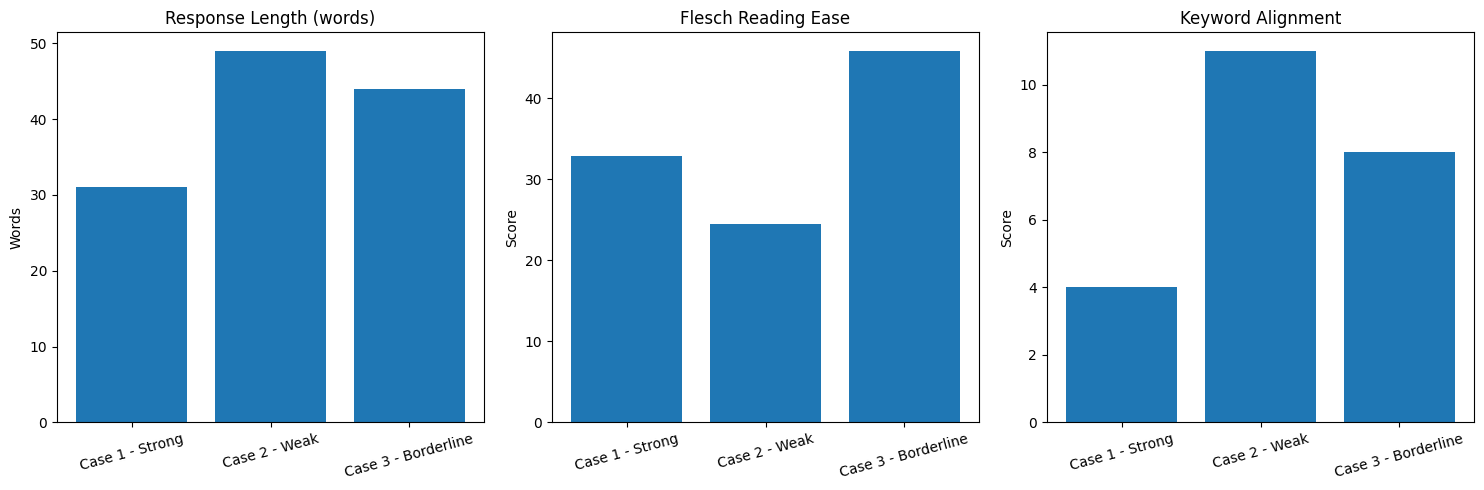

In [ ]:
plot_quantitative_results(quant_df_t1, "Template 1")

The quantitative results show that Template 1 consistently produces short and concise responses across all test cases, with **response lengths** ranging from 31 to 49 words. The longest response appears in Case 2 (Weak) with 49 words, indicating that the model provides slightly more explanation when justifying rejection, while Case 1 (Strong) has the shortest response (31 words), reflecting a straightforward approval scenario.

**The Flesch Reading Ease scores** (24.51–45.82) indicate that the responses are generally difficult to read, although Case 3 (Borderline) shows relatively better readability (45.82) compared to the others. This suggests that even with shorter responses, the language remains formal and somewhat complex.

Similarly, the **FK Grade Level** values (10.51–13.90) show that the responses require a moderate to high level of education to fully understand. Case 2 (13.90) is the most complex, while Case 3 (10.51) is comparatively simpler, aligning with the model’s attempt to simplify borderline explanations.
This level of complexity makes the responses more suitable and easier to understand for bank employees and financial professionals, while it may still be challenging for general customers.

**Keyword Alignment** varies across cases (4–11), with the highest value in Case 2 (11), indicating strong use of relevant financial terminology when explaining rejection. In contrast, Case 1 shows the lowest alignment (4), suggesting less reliance on technical terms in clear approval scenarios.

**In terms of user preference**, Template 1 is better suited for users who prefer brief and efficient decision summaries. It is more suitable for bank employees who need quick interpretations of loan outcomes, but less effective for customers who require more detailed and simplified explanations. Overall, it is preferred in scenarios where speed and brevity are prioritized over depth and detailed analysis.

Overall, the results confirm that Template 1 generates concise, relevant, and scenario-adaptive responses. However, the explanations remain relatively less detailed, with lower keyword usage in some cases and consistently low readability, which may limit understanding for general users.

## Template 2 : Detailed Financial Risk Analysis

**Qalitiative Analysis:**

In [ ]:
print("Template 2 — Output Summary")
print("=" * 60)
print(f"Test Case 1 (Strong)     : {output_1_t2}")
print("-" * 60)
print(f"Test Case 2 (Weak)       : {output_2_t2}")
print("-" * 60)
print(f"Test Case 3 (Borderline) : {output_3_t2}")
print("=" * 60)

Template 2 — Output Summary
Test Case 1 (Strong)     : The applicant appears financially very strong, exhibiting robust repayment capacity and substantial collateral, which fully supports the model's approval. Key strengths include an exceptionally high annual income of 9,600,000, an excellent CIBIL category, and significant total assets valued at 50,700,000, resulting in a strong asset to loan ratio of 1.69. While the loan amount requested is substantial, these overwhelming positive factors, alongside a manageable loan to income ratio of 3.11, effectively mitigate any associated risk, indicating a highly creditworthy borrower.
------------------------------------------------------------
Test Case 2 (Weak)       : The applicant appears financially risky despite a high annual income, primarily due to an extremely high Loan to Income Ratio of 12.50 and a very low Asset to Loan Ratio of 0.10, indicating the requested loan significantly dwarfs both income and total assets. These critical w

The following analysis evaluates the quality of the responses generated by the Gemini model for different loan application cases using Template 2. It focuses on how effectively the AI provides detailed financial explanations for the model’s decision, based on five main evaluation criteria.

**Relevance:** The responses are strongly aligned with the model's predictions, consistently explaining whether the loan is "Approved" or "Rejected" using the applicant’s financial data. In all three cases, the explanation directly supports the decision by referencing key financial indicators.

**Detail & Completeness:** The analysis is significantly more comprehensive than Template 1, as it considers multiple financial factors such as annual income, asset-to-loan ratio, loan-to-income ratio, total assets, and CIBIL category. The responses provide a balanced view by highlighting both strengths and weaknesses in the applicant’s profile rather than focusing on a single indicator.

**Clarity & Readability:** The responses are clear and well-structured, making them suitable for bank employees and financial analysts. However, due to the increased level of detail and use of financial terminology, they may be slightly more complex for general customers compared to Template 1.

**Personalization:** The responses demonstrate a moderate level of contextual relevance by incorporating the applicant’s specific financial values into the explanation. However, they still lack deeper personalization, such as user-specific context or segmentation-based insights.

**Safety & Factual Accuracy:** The model maintains high reliability by grounding the explanation in the provided financial data and avoiding unsupported claims. The responses accurately reflect the applicant’s financial situation without introducing misleading or fabricated information.

**Quantitative Analysis:**

In [ ]:
all_outputs_t2 = {
    'Case 1 - Strong': output_1_t2,
    'Case 2 - Weak': output_2_t2,
    'Case 3 - Borderline': output_3_t2,
}

quant_df_t2 = quantitative_analysis(all_outputs_t2, "Template 2")


                          Quantitative Analysis — Template 2                         
     Test Case        Response Length (words)  Flesch Reading Ease    FK Grade Level      Keyword Alignment 
    Case 1 - Strong             86                   23.13                14.31                  12         
      Case 2 - Weak             90                   27.11                13.20                  13         
Case 3 - Borderline             80                   24.57                13.81                  12         


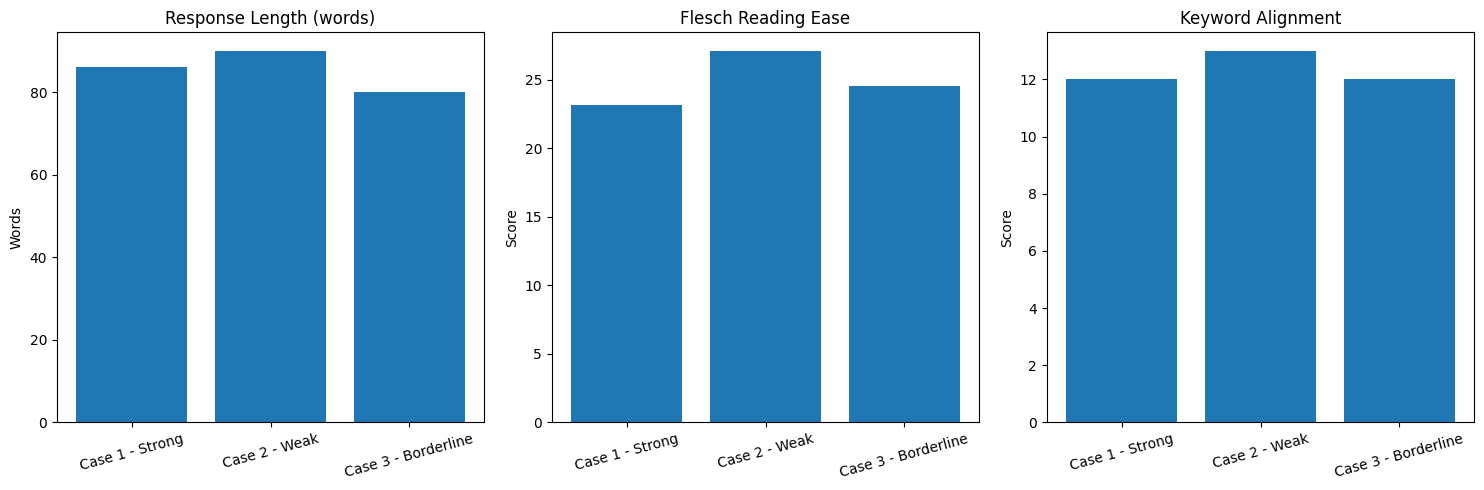

In [ ]:
plot_quantitative_results(quant_df_t2, "Template 2")

The quantitative results show that Template 2 consistently produces longer and more detailed responses compared to a brief-summary approach, with **response lengths** ranging from 80 to 90 words across all test cases. The longest response appears in Case 2 (Weak) with 90 words, indicating that the model provides more extensive explanations when the financial profile is riskier and requires clearer justification.

The **Flesch Reading Ease** scores (23–27) indicate that the responses are relatively difficult to read, reflecting a formal and technical writing style suitable for financial analysis. Similarly, the **FK Grade Level** values (13.20–14.31) suggest that the explanations require a higher level of education to fully understand, which aligns with the template’s purpose of targeting bank employees and financial analysts rather than general customers.

**Keyword Alignment** remains consistently high across all cases (12–13), demonstrating strong use of domain-specific terminology such as loan, risk, income, and assets. This indicates that the model maintains high relevance to the financial domain regardless of the applicant profile.

In terms of **user preference**, Template 2 is more suitable for users who require detailed and analytical explanations rather than quick summaries. The longer responses and strong use of financial terminology make the template useful for financial analysts and bank employees who need deeper understanding of the model’s reasoning. However, the lower readability scores and more technical language may make the responses less suitable for general customers or non-expert users.

Overall, the results confirm that Template 2 produces detailed, domain-relevant, and analytically rich explanations, but at the cost of lower readability, especially for non-expert users.

## Template 3 : Loan Improvement Advisor

**Qualitative Analysis:**

In [ ]:
# Display All Outputs for Template 3
print("Template 3 — Output Summary")
print("=" * 60)
print(f"Test Case 1 (Strong)     : {output_1_t3}")
print("-" * 60)
print(f"Test Case 2 (Weak)       : {output_2_t3}")
print("-" * 60)
print(f"Test Case 3 (Borderline) : {output_3_t3}")
print("=" * 60)

Template 3 — Output Summary
Test Case 1 (Strong)     : Your loan application has been approved. This decision is primarily based on your exceptionally strong financial profile, including a high annual income, substantial total assets providing robust collateral, and an excellent CIBIL category.
------------------------------------------------------------
Test Case 2 (Weak)       : Your loan application has been rejected primarily due to the high financial risk associated with the requested loan amount relative to your current income and assets, combined with your low CIBIL category. Specifically, your Loan to Income Ratio is exceptionally high at 12.50, and your total assets cover only 10% of the requested loan amount.

To improve your chances of approval in the future, we recommend:
1.  **Improve Creditworthiness:** Focus on improving your CIBIL category by consistently managing existing credit obligations and promptly addressing any outstanding debts.
2.  **Adjust Loan Request:** Con

The following analysis evaluates the quality of the responses generated by the Gemini model for different loan application cases using Template 3. This template focuses not only on explaining the loan decision, but also on providing practical recommendations for rejected applications. The evaluation is based on five main criteria.

**Relevance**: The responses are highly aligned with the model's predictions across all three cases. In Case 1, the approved decision is supported by the applicant’s strong financial profile, high income, substantial assets, and excellent CIBIL category. In Cases 2 and 3, the rejected decisions are explained using relevant financial risk factors such as high loan-to-income ratio, weak asset coverage, and CIBIL category.

**Detail & Completeness**: Template 3 provides more complete responses compared to short explanation templates. The approved case remains concise, while the rejected cases include both the reason for rejection and three practical recommendations. This makes the responses more informative, especially for employees who need to explain decisions and provide useful guidance to customers.

**Clarity & Readability**: The responses are clear and professionally written. However, the rejected cases contain more financial terms and longer explanations, which may be more suitable for bank employees than general customers. The structured recommendation format improves readability by separating the explanation from the suggested actions.

**Personalization**: The responses show a good level of personalization because they refer to the applicant’s specific financial indicators, such as the loan-to-income ratio, asset-to-loan ratio, annual income, assets, and CIBIL category. The rejected cases are especially personalized because the recommendations directly address the applicant’s weaknesses.

**Safety & Factual Accuracy**: The model remains mostly grounded in the provided applicant information and does not introduce unrelated financial claims. The recommendations are general and practical, such as reducing the requested loan amount, improving creditworthiness, and strengthening income or assets, which makes them appropriate for decision-support use.

**Quantitative Analysis:**

In [ ]:
# --- Template 3 Outputs ---
all_outputs_t3 = {
    'Case 1 - Strong'     : output_1_t3,
    'Case 2 - Weak'       : output_2_t3,
    'Case 3 - Borderline' : output_3_t3,
}

quant_df_t3 = quantitative_analysis(
    all_outputs_t3,
    "Template 3",
    include_recommendations=True
)


                          Quantitative Analysis — Template 3                         
     Test Case        Response Length (words)  Flesch Reading Ease    FK Grade Level      Keyword Alignment   Recommendation Signals
    Case 1 - Strong             33                   13.20                15.52                   6                     0           
      Case 2 - Weak            135                   25.58                14.48                  22                     6           
Case 3 - Borderline            110                   21.33                14.84                  21                     5           


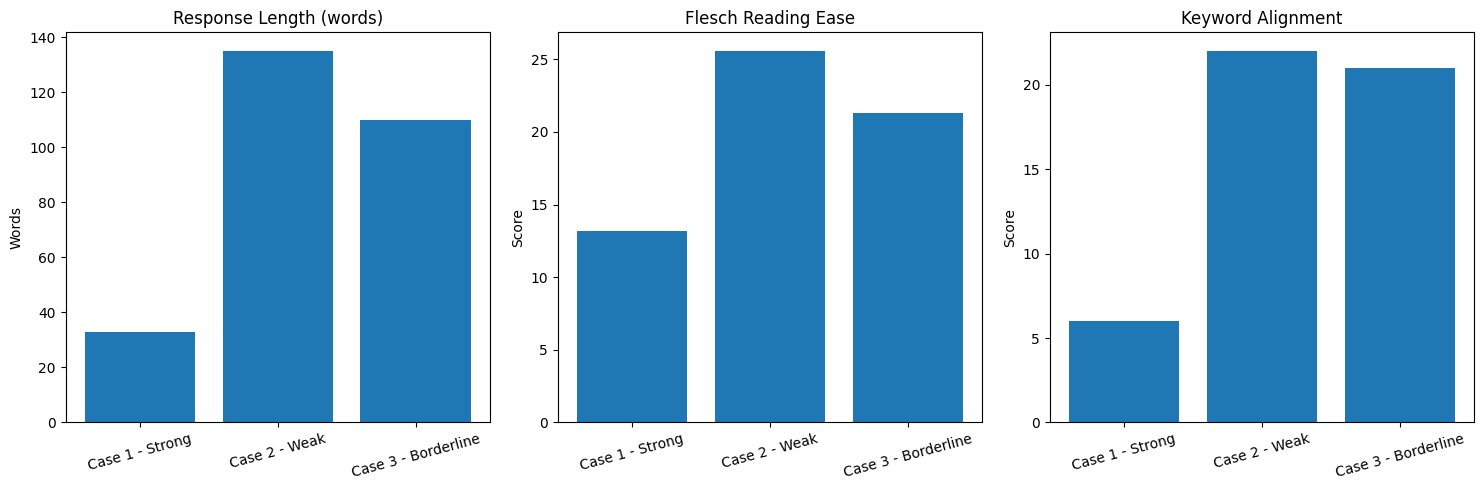

In [ ]:
plot_quantitative_results(quant_df_t3, "Template 3")

The quantitative results show that Template 3 adapts its response length based on the decision outcome. Case 1 (Strong) has the shortest response with 33 words because the application is approved and only requires a brief justification. In contrast, Case 2 (Weak) has the longest response with 135 words, followed by Case 3 (Borderline) with 110 words. This increase is expected because rejected cases include both an explanation and three improvement recommendations.

**The Flesch Reading Ease scores** range from 13.20 to 25.58, indicating that the responses are generally difficult to read. Case 2 has the highest readability score (25.58), while Case 1 has the lowest score (13.20), likely because the approval explanation uses formal financial wording in a compact sentence. Overall, the responses are professional but may still require some financial understanding.

Similarly, the **FK Grade Level** values range from 14.48 to 15.52, showing that the generated responses use relatively advanced language. Case 1 has the highest FK Grade Level (15.52), while Case 2 has the lowest (14.48). This suggests that although Template 3 provides useful explanations, the language remains more suitable for bank employees than for customers with limited financial knowledge.

**Keyword Alignment** is highest in the rejected cases, with 22 in Case 2 and 21 in Case 3, compared to only 6 in Case 1. This shows that the model uses more loan-related and financial terminology when explaining rejection decisions. The lower keyword alignment in the approved case is expected because the response is shorter and does not require detailed risk explanation.

**Recommendation Signals** appear only in the rejected cases, with 6 signals in Case 2 and 5 signals in Case 3, while Case 1 has 0. This confirms that Template 3 follows its intended purpose by providing actionable advice only when the application is rejected. The recommendations focus on improving creditworthiness, reducing the requested loan amount, and strengthening income or assets.

**In terms of user preference**, Template 3 is more suitable for bank employees who need both decision explanations and practical guidance to communicate with customers. It is especially useful for rejection and borderline cases because it provides constructive next steps rather than only stating the reason for rejection. However, it may be less suitable for users who prefer very short decision summaries, since the advisory structure naturally produces longer responses.

Overall, the results confirm that Template 3 provides relevant, personalized, and actionable responses. It performs particularly well in rejected cases by combining financial explanation with improvement advice. However, the responses are longer and less readable than simpler templates, which reflects the trade-off between depth, usefulness, and simplicity.

## Template 4 : Customer-Friendly Loan Explanation

**Qualitative Analysis:**

In [ ]:
# Display All Outputs for Template 4
print("Template 4 — Output Summary")
print("=" * 60)
print(f"Test Case 1 (Strong)     : {output_1_t4}")
print("-" * 60)
print(f"Test Case 2 (Weak)       : {output_2_t4}")
print("-" * 60)
print(f"Test Case 3 (Borderline) : {output_3_t4}")
print("=" * 60)

Template 4 — Output Summary
Test Case 1 (Strong)     : Hello there! I have some wonderful news regarding your loan application – it's been approved! Our system looked at your strong credit history, good income, and valuable assets, which clearly demonstrate your solid financial standing. We're very pleased to support customers like yourself who are looking for a substantial loan. Congratulations, and we're excited to help you move forward with your plans!
------------------------------------------------------------
Test Case 2 (Weak)       : Hi there! Thank you for your patience while we reviewed your loan application. Our system has indicated that we won't be able to approve it at this time, mainly because the amount requested is quite substantial compared to your current annual income and available assets, alongside a weaker history of past financial dealings. We understand that as a modest-income applicant, it can be challenging to meet these requirements for a large loan, but pleas

The following analysis evaluates the quality of the responses generated by the Gemini model for different loan application cases using Template 4. It focuses on how effectively the AI delivers a friendly, supportive, and easy-to-understand explanation of the model's decision for non-expert customers, based on five main evaluation criteria.

**Relevance:** The responses are well aligned with the model's predictions and clearly communicate whether the loan was approved or rejected in all cases. In Test Case 1, the approval is supported by strong financial indicators such as good income, valuable assets, and a strong credit history. In Test Cases 2 and 3, the rejection is clearly explained by the imbalance between the requested loan amount and the applicant's income and assets, making the responses relevant and grounded in the applicant's financial situation.

**Detail & Completeness:** The responses provide sufficient detail for a non-expert user to understand the key reasons behind each decision. Important factors such as income level, loan size, asset value, and overall financial standing are clearly mentioned. In rejection cases, the responses also include helpful suggestions, such as improving credit history, increasing savings, or considering a smaller loan amount, which adds practical value without overwhelming the user.

**Clarity & Readability:** The responses are clear, concise, and easy to read, using simple and conversational language. Technical financial terminology is minimized, making the explanations accessible to users with no financial background. The friendly tone further enhances readability and user engagement.

**Personalization:** The responses demonstrate good personalization by adapting both tone and content based on the applicant's situation. For example, in Test Case 2, the message acknowledges the applicant's financial limitations while maintaining an empathetic tone. In Test Case 3, the explanation is tailored to the borderline scenario by focusing on the mismatch between loan amount and financial capacity, making the response feel relevant and user-specific.

**Safety & Factual Accuracy:** The responses remain consistent with the model's predictions and avoid introducing unsupported claims. The tone is carefully managed, especially in rejection cases, where the system provides encouragement and constructive suggestions without making unrealistic promises. This ensures that the responses are both reliable and ethically appropriate for customer-facing communication.

**Quantitative Analysis:**

In [ ]:
# --- Template 4 Outputs ---
all_outputs_t4 = {
    'Case 1 - Strong'     : output_1_t4,
    'Case 2 - Weak'       : output_2_t4,
    'Case 3 - Borderline' : output_3_t4,
}

quant_df_t4 = quantitative_analysis(
    all_outputs_t4,
    "Template 4",
    include_recommendations=True
)


                          Quantitative Analysis — Template 4                         
     Test Case        Response Length (words)  Flesch Reading Ease    FK Grade Level      Keyword Alignment   Recommendation Signals
    Case 1 - Strong             62                   51.28                 9.90                  5                      0           
      Case 2 - Weak             95                   37.57                13.92                  5                      1           
Case 3 - Borderline             94                   53.38                11.65                  4                      1           


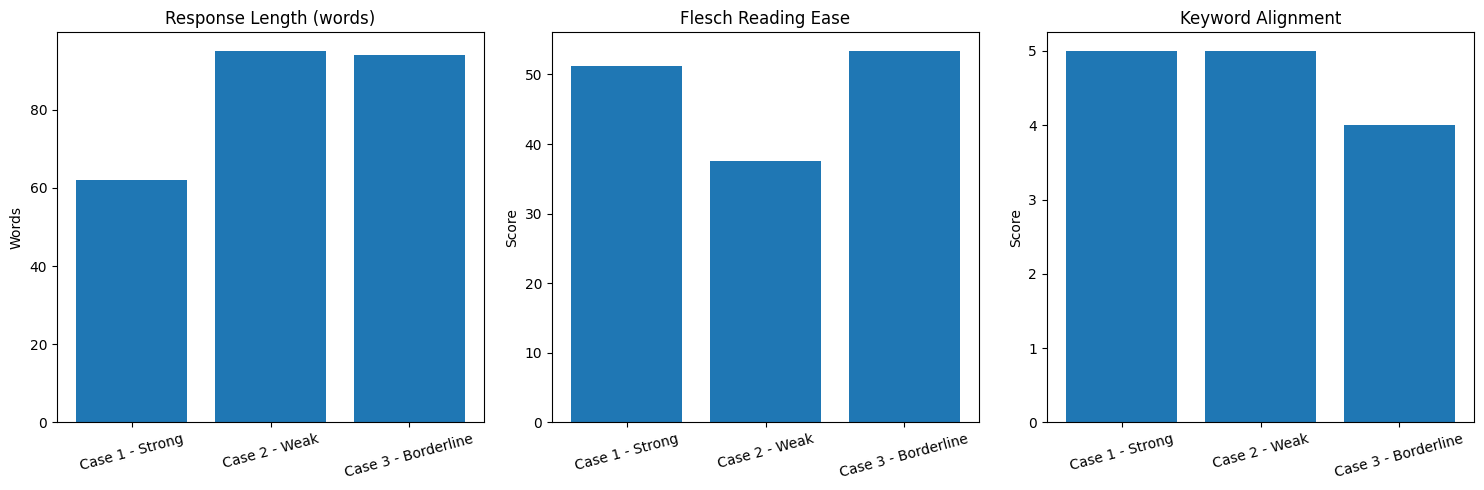

In [ ]:
plot_quantitative_results(quant_df_t4, "Template 4")

The quantitative results show that Template 4 produces responses that are moderate to long in length while maintaining generally good readability across all three test cases. The response length ranges from 62 words in the strong case to 95 words in the weak case and 94 words in the borderline case, indicating that the template provides detailed explanations without being excessively verbose.

**The Flesch Reading Ease scores** (51.28, 37.57, and 53.38) suggest that the responses range from moderately easy to slightly difficult to read, with the weak case being more complex due to longer explanatory content. Similarly, **the FK Grade Level** values (9.90, 13.92, and 11.65) indicate that the language varies from fairly accessible to more advanced, reflecting the increased detail in rejection scenarios.

**The Keyword Alignment scores** are consistent in the strong and weak cases (5) and slightly lower in the borderline case (4), showing that Template 4 still captures important financial concepts while prioritizing natural, user-friendly language over strict use of domain-specific keywords.

**The Recommendation Signals** are limited, with 0 in the strong case and 1 in both the weak and borderline cases, indicating that while the template provides some guidance in rejection scenarios, it does so in a simplified and less structured manner compared to more advisory-focused templates.

**In terms of user preference simulation**, Template 4 is well-suited for customer-facing communication. Its combination of supportive tone, clear explanations, and moderate detail makes it appropriate for applications such as banking apps and customer service platforms. However, compared to more technical templates, it offers less analytical depth and may be less suitable for internal financial evaluation.

Overall, the results confirm that Template 4 effectively balances clarity, personalization, and usability, making it highly appropriate for non-expert users while intentionally reducing technical complexity to enhance the customer experience.

# 6.Best Prompt Selection & Justification

In this section, the best prompt template is selected based on the results of the qualitative and quantitative analysis. The selection is not based only on the length of the response, but on how well the template supports the overall goal of the loan approval system. A strong prompt template should explain the model decision clearly, remain aligned with the applicant’s financial data, avoid unsupported assumptions, and provide useful information that can help bank employees communicate the decision effectively.

The qualitative results are used to compare the templates based on relevance, clarity, completeness, personalization, and safety, focusing on how effectively each template supports decision communication. The quantitative results provide supporting evidence through measurable metrics. Response Length evaluates the level of detail, Flesch Reading Ease and FK Grade Level assess readability, Keyword Alignment measures domain relevance, and Recommendation Signals indicate the presence of actionable advice in advisory templates.


## System Goal and Intended Workflow


The main goal of this system is to support bank employees, loan officers, and financial reviewers in understanding and communicating loan decisions. The system is not intended to fully replace human judgment or directly communicate final loan decisions to customers without employee review. Loan approval decisions are sensitive and may significantly affect customers, so the Generative AI component should work as a decision-support layer that helps employees interpret the machine learning output, understand the applicant’s financial situation, and communicate the result responsibly.


## Fair Comparison Setup

To ensure that the prompt selection process is fair and controlled, all four templates were evaluated under a consistent experimental setup. The same Gemini model was used to generate the responses, and the same supervised model prediction was used as the main decision source across all templates. The same three applicant profiles were also used for testing: strong, weak, and borderline. This ensures that differences in the outputs come mainly from the prompt design rather than from different input data, model versions, or evaluation settings.

The templates also share the same core applicant information, including income, loan amount, asset values, loan term, CIBIL category, loan-to-income ratio, total assets, and asset-to-loan ratio. Templates 3 and 4 additionally use the applicant profile group from clustering because their designs include personalization. This difference does not make the comparison unfair because it reflects their intended purpose and integration with the unsupervised learning component.

The quantitative evaluation was also applied consistently using the same analysis function and the same metrics: Response Length, Flesch Reading Ease, FK Grade Level, and Keyword Alignment. Recommendation Signals were added for templates that provide improvement guidance, and templates without recommendation-oriented outputs were assigned a value of 0 for comparison purposes. Therefore, the comparison is based on a controlled setup while still allowing each template to demonstrate its intended role.

Although the templates have different purposes, this supports the comparison rather than weakening it. Template 1 focuses on brief summaries, Template 2 focuses on detailed financial analysis, Template 3 focuses on decision explanation with improvement recommendations, and Template 4 focuses on simplified customer-friendly communication. Since the setup, input cases, model source, and evaluation criteria are consistent, the comparison can determine which template best supports the final system workflow.

## Combined Quantitative Comparison



In [ ]:
# --- Quantitative Results from Current Run ---

# These values are copied from the current executed outputs to preserve
# the same results used in the written analysis and avoid regenerating
# Gemini responses.

quant_df_t1 = pd.DataFrame([
    {
        'Test Case': 'Case 1 - Strong',
        'Response Length (words)': 31,
        'Flesch Reading Ease': 32.82,
        'FK Grade Level': 12.53,
        'Keyword Alignment': 4
    },
    {
        'Test Case': 'Case 2 - Weak',
        'Response Length (words)': 49,
        'Flesch Reading Ease': 24.51,
        'FK Grade Level': 13.90,
        'Keyword Alignment': 11
    },
    {
        'Test Case': 'Case 3 - Borderline',
        'Response Length (words)': 44,
        'Flesch Reading Ease': 45.82,
        'FK Grade Level': 10.51,
        'Keyword Alignment': 8
    }
])

quant_df_t2 = pd.DataFrame([
    {
        'Test Case': 'Case 1 - Strong',
        'Response Length (words)': 86,
        'Flesch Reading Ease': 23.13,
        'FK Grade Level': 14.31,
        'Keyword Alignment': 12
    },
    {
        'Test Case': 'Case 2 - Weak',
        'Response Length (words)': 90,
        'Flesch Reading Ease': 27.11,
        'FK Grade Level': 13.20,
        'Keyword Alignment': 13
    },
    {
        'Test Case': 'Case 3 - Borderline',
        'Response Length (words)': 80,
        'Flesch Reading Ease': 24.57,
        'FK Grade Level': 13.81,
        'Keyword Alignment': 12
    }
])

quant_df_t3 = pd.DataFrame([
    {
        'Test Case': 'Case 1 - Strong',
        'Response Length (words)': 33,
        'Flesch Reading Ease': 13.20,
        'FK Grade Level': 15.52,
        'Keyword Alignment': 6,
        'Recommendation Signals': 0
    },
    {
        'Test Case': 'Case 2 - Weak',
        'Response Length (words)': 135,
        'Flesch Reading Ease': 25.58,
        'FK Grade Level': 14.48,
        'Keyword Alignment': 22,
        'Recommendation Signals': 6
    },
    {
        'Test Case': 'Case 3 - Borderline',
        'Response Length (words)': 110,
        'Flesch Reading Ease': 21.33,
        'FK Grade Level': 14.84,
        'Keyword Alignment': 21,
        'Recommendation Signals': 5
    }
])

quant_df_t4 = pd.DataFrame([
    {
        'Test Case': 'Case 1 - Strong',
        'Response Length (words)': 62,
        'Flesch Reading Ease': 51.28,
        'FK Grade Level': 9.90,
        'Keyword Alignment': 5,
        'Recommendation Signals': 0
    },
    {
        'Test Case': 'Case 2 - Weak',
        'Response Length (words)': 95,
        'Flesch Reading Ease': 37.57,
        'FK Grade Level': 13.92,
        'Keyword Alignment': 5,
        'Recommendation Signals': 1
    },
    {
        'Test Case': 'Case 3 - Borderline',
        'Response Length (words)': 94,
        'Flesch Reading Ease': 53.38,
        'FK Grade Level': 11.65,
        'Keyword Alignment': 4,
        'Recommendation Signals': 1
    }
])

In [ ]:
from IPython.display import display

# --- Quantitative Comparison Tables by Test Case ---

metrics = [
    "Response Length (words)",
    "Flesch Reading Ease",
    "FK Grade Level",
    "Keyword Alignment",
    "Recommendation Signals"
]

case_order = [
    "Case 1 - Strong",
    "Case 2 - Weak",
    "Case 3 - Borderline"
]

template_order = [
    "Template 1",
    "Template 2",
    "Template 3",
    "Template 4"
]

combined_quant_df = pd.concat([
    quant_df_t1.assign(Template="Template 1"),
    quant_df_t2.assign(Template="Template 2"),
    quant_df_t3.assign(Template="Template 3"),
    quant_df_t4.assign(Template="Template 4"),
], ignore_index=True)

for case in case_order:
    case_df = combined_quant_df[
        combined_quant_df["Test Case"] == case
    ]

    table_data = {}

    for template in template_order:
        row = case_df[case_df["Template"] == template].iloc[0]
        table_data[template] = [row[metric] for metric in metrics]

    case_comparison_df = pd.DataFrame(
        table_data,
        index=metrics
    )

    case_comparison_df.index.name = "Metric"

    styled_case_df = (
        case_comparison_df.style
        .format("{:.2f}")
        .set_caption(f"Quantitative Comparison — {case}")
        .set_properties(**{
            "text-align": "center"
        })
    )

    display(styled_case_df)

,Template 1,Template 2,Template 3,Template 4
Metric,,,,
Response Length (words),31.00,86.00,33.00,62.00
Flesch Reading Ease,32.82,23.13,13.20,51.28
FK Grade Level,12.53,14.31,15.52,9.90
Keyword Alignment,4.00,12.00,6.00,5.00
Recommendation Signals,nan,nan,0.00,0.00


,Template 1,Template 2,Template 3,Template 4
Metric,,,,
Response Length (words),49.00,90.00,135.00,95.00
Flesch Reading Ease,24.51,27.11,25.58,37.57
FK Grade Level,13.90,13.20,14.48,13.92
Keyword Alignment,11.00,13.00,22.00,5.00
Recommendation Signals,nan,nan,6.00,1.00


,Template 1,Template 2,Template 3,Template 4
Metric,,,,
Response Length (words),44.00,80.00,110.00,94.00
Flesch Reading Ease,45.82,24.57,21.33,53.38
FK Grade Level,10.51,13.81,14.84,11.65
Keyword Alignment,8.00,12.00,21.00,4.00
Recommendation Signals,nan,nan,5.00,1.00


In [ ]:
from IPython.display import display

# --- Average Metrics per Template ---

template_summary_df = combined_quant_df.groupby("Template").agg({
    "Response Length (words)": "mean",
    "Flesch Reading Ease": "mean",
    "FK Grade Level": "mean",
    "Keyword Alignment": "mean",
    "Recommendation Signals": "mean"
}).reset_index()

template_summary_df = template_summary_df.round(2)

# Transpose summary table: metrics as rows, templates as columns
template_summary_view = template_summary_df.set_index("Template").T

template_summary_view.index.name = "Metric"

format_rules = {
    "Template 1": "{:.2f}",
    "Template 2": "{:.2f}",
    "Template 3": "{:.2f}",
    "Template 4": "{:.2f}"
}

styled_template_summary = (
    template_summary_view.style
    .format(format_rules)
    .set_caption("Average Quantitative Metrics by Template")
    .set_properties(**{
        "text-align": "center"
    })
)

display(styled_template_summary)

Template,Template 1,Template 2,Template 3,Template 4
Metric,,,,
Response Length (words),41.33,85.33,92.67,83.67
Flesch Reading Ease,34.38,24.94,20.04,47.41
FK Grade Level,12.31,13.77,14.95,11.82
Keyword Alignment,7.67,12.33,16.33,4.67
Recommendation Signals,nan,nan,3.67,0.67


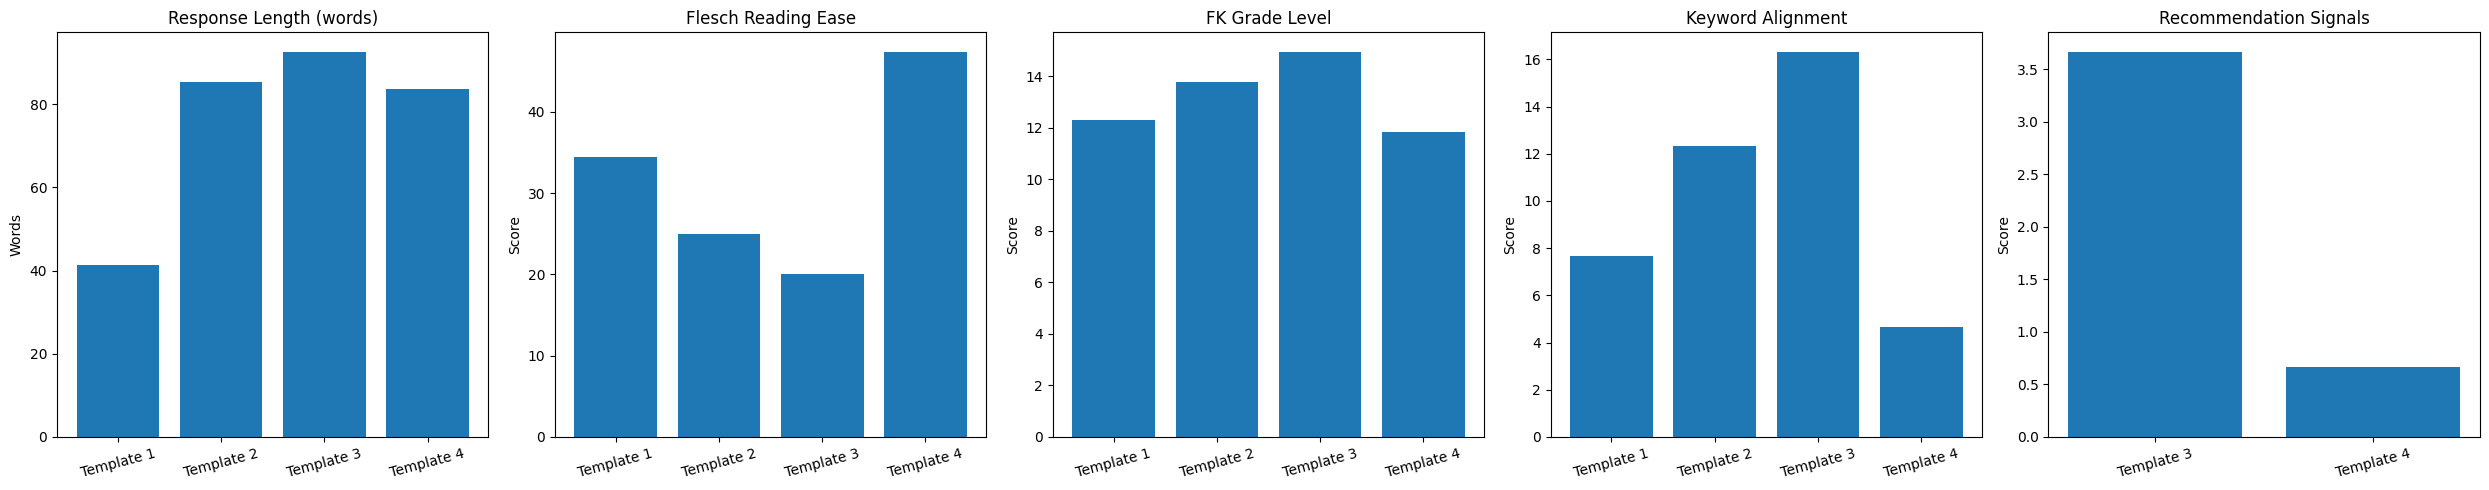

In [ ]:
# --- Overall Quantitative Visualization Across Templates ---

def plot_template_summary(summary_df):
    metrics = [
        "Response Length (words)",
        "Flesch Reading Ease",
        "FK Grade Level",
        "Keyword Alignment",
        "Recommendation Signals"
    ]

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))

    for ax, metric in zip(axes, metrics):
        ax.bar(summary_df["Template"], summary_df[metric])
        ax.set_title(metric)
        ax.set_ylabel("Score" if metric != "Response Length (words)" else "Words")
        ax.tick_params(axis="x", rotation=15)

    plt.tight_layout()
    plt.savefig("results/AllTemplates_quantitative_comparison.png")
    plt.show()


plot_template_summary(template_summary_df)

The combined quantitative table and overall comparison charts summarize the performance of all templates in one place. This makes it easier to compare the templates based on response length, readability, domain relevance, and advisory strength. The table also helps identify trade-offs between templates, such as the difference between readability and financial detail.

## Qualitative Comparison Summary

| Criteria | Template 1 | Template 2 | Template 3 | Template 4 |
|---|---|---|---|---|
| Relevance | High | High | High | High |
| Detail & Completeness | Low to Moderate | High | High | Moderate |
| Clarity & Readability | Moderate |  Moderate to Low | Moderate | High |
| Personalization | Low | Moderate | High | High |
| Safety & Factual Accuracy | High | High | High | High |
| Actionable Guidance | Low | Low | High | Moderate |
| Best Use Case | Quick summary | Internal financial analysis | Employee decision support | Customer-facing explanation |

The qualitative comparison shows that all templates remain relevant and factually grounded, but they differ in how much support they provide for the final system workflow. Template 1 is efficient but limited, Template 2 is analytical but lacks guidance, Template 4 is highly readable but less technical, and Template 3 provides the strongest combination of financial explanation and actionable support for bank employees.

## Summary of Templates Performance

The combined quantitative and qualitative results show that each template performs differently based on its intended purpose.

**Template 1** produces the shortest responses, with response lengths ranging from 31 to 49 words. This makes it useful for quick decision summaries, but the qualitative analysis shows that it lacks depth and personalization because it focuses mainly on one or two financial indicators. Its Keyword Alignment ranges from 4 to 11, which shows that it can remain domain-relevant in rejection cases, but it does not provide enough detail for more complex or borderline applications.

**Template 2** provides deeper financial analysis than Template 1. Its responses are longer, ranging from 80 to 90 words, and its Keyword Alignment remains consistently high between 12 and 13. This shows that Template 2 is strong in financial interpretation and domain relevance. However, it does not provide recommendations or next steps, which limits its usefulness for employees who need to guide customers after a rejection. Its Flesch Reading Ease scores also remain low, between 23.13 and 27.11, indicating that the responses are more complex and better suited for internal financial review than practical decision communication.

**Template 3** provides both decision explanation and practical recommendations. It adapts its response length based on the decision outcome, producing a short response for the approved case with 33 words and longer responses for rejected cases with 135 and 110 words. This behavior matches the purpose of the template because rejected applications require more explanation and guidance. It also has the highest Keyword Alignment in rejection cases, with scores of 22 and 21, showing strong relevance to the loan approval domain. In addition, Recommendation Signals appear only in rejected cases, with scores of 6 and 5, while the approved case has 0, confirming that the template provides advice only when it is needed.

**Template 4** provides the strongest readability and most customer-friendly tone. Its responses are moderate in length, ranging from 62 to 95 words, and its Flesch Reading Ease scores (51.28, 37.57, and 53.38) are generally higher than the other templates, making the outputs easier for non-expert users to understand. However, its Keyword Alignment remains lower, between 4 and 5, because the template simplifies financial concepts instead of using domain-specific terminology. Recommendation Signals are also limited (0, 1, and 1), indicating that it offers only light guidance in rejection cases. This makes Template 4 highly effective for customer-facing communication, but less suitable for detailed internal financial analysis or employee decision support.

## Comparison Between Templates

Based on the combined results, Template 3 and Template 4 outperform Template 1 and Template 2 for the final Generative AI system. Template 1 is too brief for complex cases, even though it is useful for fast summaries. Template 2 provides strong financial analysis and stable keyword alignment, but it does not provide actionable recommendations. Therefore, both templates are useful in specific scenarios, but they do not fully support the final decision-support workflow.

Template 3 and Template 4 both improve the usefulness of the output by going beyond basic decision explanation. Template 3 adds structured recommendations for rejected applicants, while Template 4 improves readability and customer experience by simplifying financial language. This makes the comparison between them more difficult because both templates are strong, but they optimize for different goals.

Template 4 performs better in readability, with the highest Flesch Reading Ease scores among all templates. This makes it suitable for direct customer-facing communication, such as mobile banking applications or customer portals. However, its lower Keyword Alignment scores show that it intentionally reduces technical financial detail. While this improves accessibility, it also makes the response less suitable for internal decision review.

Template 3 performs better in domain relevance and advisory usefulness. Its rejected-case Keyword Alignment scores of 22 and 21 are the highest among all templates, and its Recommendation Signals of 6 and 5 show that it provides practical guidance when the application is rejected. Although Template 3 is less readable than Template 4, it better supports the bank employee’s role because it preserves important financial reasoning and provides recommendations that can be reviewed before being communicated to the customer.

For this reason, the final selection will be based on the intended workflow of the system.

## Final Selected Template

**Template 3: Loan Improvement Advisor** is selected as the best prompt template for the final system. It provides the strongest alignment with the system’s intended workflow because it supports employees in both understanding the decision and giving constructive guidance. Unlike Template 4, which simplifies the explanation mainly for customers, Template 3 keeps important financial indicators such as loan-to-income ratio, asset-to-loan ratio, total assets, income, and CIBIL category. This makes the response more useful for employees who need to evaluate the reasoning before communicating with the customer.

From the qualitative perspective, Template 3 performs strongly in relevance, completeness, personalization, and safety. The responses are aligned with the model predictions across all test cases. In the approved case, the response highlights the applicant’s strong income, assets, and CIBIL category. In the rejected cases, the explanations are based on clear financial risk factors, such as high loan-to-income ratio, weak asset coverage, and low or medium CIBIL category. The recommendations are also directly connected to the applicant’s weaknesses, such as reducing the requested loan amount, improving creditworthiness, and strengthening income or assets.

From the quantitative perspective, Template 3 provides the strongest evidence of action-oriented decision support. Its rejected-case responses are longer than the other templates because they include both explanation and three practical recommendations. Although this reduces readability compared to Template 4, it increases usefulness for employee decision support.Template 3 also achieves the highest domain relevance in rejected cases, with Keyword Alignment scores of 22 and 21, compared with Template 4’s lower rejected-case scores of 5 and 4. The Recommendation Signals further support the selection, since Template 3 records 6 signals in Case 2 and 5 in Case 3, while the approved case correctly records 0.

In terms of alignment with the system goals, Template 3 is the most appropriate final choice because the system is intended to support responsible loan decision communication through bank employees. It does not only explain whether the application is approved or rejected, but also provides practical, financially grounded guidance that employees can use when discussing rejection or borderline cases with customers. This is important because loan decisions should remain supervised by a human employee, especially when customers may prefer receiving sensitive financial decisions from an official bank representative rather than directly from an automated system. For example, some elderly customers may not feel comfortable using a chatbot or trusting an automated message for an important financial decision. In such cases, a bank employee can use the generated explanation and recommendations to communicate the decision in a clear, respectful, and human-centered way.


Overall, Template 3 was selected as the best prompt template because it provides the best balance between explanation quality, financial relevance, personalization, actionable recommendations, and alignment with the bank employee decision-support workflow. Template 4 remains valuable for customer-facing communication, Template 2 remains useful for internal financial analysis, and Template 1 remains useful for quick summaries. However, Template 3 is the most suitable final template because it directly supports the main purpose of the system: helping bank employees interpret machine learning decisions and communicate them clearly, responsibly, and constructively.

# 7.Integration Plan for Final System

The final system will integrate the supervised learning model, clustering model, and Generative AI model to provide explainable and personalized loan decision support. When a bank employee enters the applicant’s financial information into the system, the data is first processed by the trained supervised learning model (Random Forest) to predict whether the loan application should be approved or rejected.

At the same time, the applicant’s financial features are passed to the clustering component (KMeans model) to identify the applicant’s financial profile group, such as Modest-income applicant, Moderate financial profile applicant, or Affluent / large-loan applicant. This clustering step adds contextual understanding and allows the system to generate more personalized explanations and recommendations based on the applicant’s overall financial segment.

After both the prediction result and cluster profile are generated, the applicant’s financial features, prediction outcome, and profile group are passed to Template 3. The template structures these inputs into a prompt that is sent to the Gemini API. Gemini then generates a natural-language explanation of the decision and, in rejection or borderline cases, provides practical recommendations to help improve future loan eligibility.

The generated response is returned to the system interface and displayed to the bank employee alongside the prediction result and applicant profile group. Employees can review the explanation and recommendations before communicating the decision to the customer. This integration combines supervised learning for prediction, unsupervised learning for personalization, and Generative AI for explanation generation, allowing the system to provide transparent, contextual, and actionable decision support.

# 8.Ethical Considerations & Limitations


This section discusses the ethical risks, practical limitations, and possible improvements of integrating Generative AI into the loan approval system.


## Ethical Considerations


**Bias in Financial Data:**  The supervised model is trained on historical loan data, which may include biases related to socio-economic factors such as income level, employment type, or credit history. As a result, the model may learn patterns that unintentionally disadvantage certain groups. Since the generative AI explanations are based on these predictions, they may also reflect the same biases while appearing reasonable and neutral.

**Fairness in Decision Communication:**  Even when two applicants have similar financial situations, differences in model predictions or cluster assignments may lead to different explanations. This creates a fairness concern, especially if AI-generated explanations make borderline decisions sound definitive or fully justified.

**Privacy of Customer Data:**  The system uses sensitive financial information (e.g., income, loan amount, assets) to generate explanations through an external API. This means that customer data is processed outside the core system, which raises privacy concerns. Proper safeguards such as data minimization, secure transmission, and careful handling of customer information are required.

**API Key Security:**  The Gemini API key is stored in a `.env` file, which is a good practice. However, if not properly protected, it can be exposed or misused. Secure storage, restricted access, and periodic key rotation are necessary to reduce the risk of unauthorized usage.

**AI Hallucination Risk:**  Generative AI models may sometimes produce explanations that sound confident but are not fully grounded in the input data. In a financial context, this can mislead customers about the true reasons behind a decision. Therefore, explanations should remain consistent with model outputs and avoid unsupported claims.

**Over-Reliance on AI Explanations:**  There is a risk that customers or employees may treat AI-generated explanations as the final decision rationale. This can reduce critical thinking and human judgment, especially in sensitive or borderline cases. The system should be treated as a decision-support tool rather than a final authority.

## Limitations


**Model Dependency:**  The system relies on a specific combination of models (Random Forest for prediction and KMeans for clustering). If the data distribution changes or new patterns emerge, these models may not perform optimally, and the generated explanations will reflect those limitations.

**Cluster-Based Personalization:**  Personalization is based on cluster profiles, which are simplified group representations. While useful, they do not fully capture individual differences, meaning some explanations may not perfectly reflect a specific customer’s situation.

**API Dependency and Quota Limits:**  The explanation component depends on the Gemini API. During testing, quota limits (e.g., HTTP 429 errors) may prevent responses from being generated. This can affect system reliability even when predictions and clustering work correctly.

**Limited Context Awareness:**  The system generates explanations based only on the provided features. It does not consider additional context such as long-term financial behavior, market conditions, or previous interactions with the bank, which limits the depth of explanations.

**Reproducibility Across Environments:**  Although the required files and configurations exist, results may vary across environments (e.g., local machine vs. Google Colab) due to differences in setup, package versions, or API configuration.

## Potential Improvements


**Bias Monitoring and Mitigation:**  Introduce fairness evaluation metrics and regularly monitor model performance across different customer groups. Retraining with more balanced data can help reduce bias.

**Human-in-the-Loop Validation:**  Include a review step for critical or borderline cases, where a human expert validates or adjusts the AI-generated explanation before presenting it to the customer.

**Improved Prompt Engineering:**  Enhance prompts to enforce stronger grounding in model outputs, improve consistency, and handle edge cases more effectively.

**API Reliability Enhancements:**  Implement retry mechanisms with exponential backoff, caching of responses, and fallback strategies to handle API failures or quota limits.

**Multilingual Support:**  Extend the system to support multiple languages (e.g., Arabic) to improve accessibility and usability for a wider range of customers.

**Richer Context Integration:**  Incorporate additional data such as repayment history, financial trends, and behavioral patterns to generate more accurate and personalized explanations.

Overall, while the system successfully enhances interpretability and improves decision communication support, it introduces important trade-offs related to fairness, reliability, and dependency on external services. Addressing these challenges is essential for ensuring safe and effective deployment in real-world environments.